# 3A - Indices fisicos semanais do Nino 3.4

**Pergunta especifica.** Quais series fisicas descrevem o estado do sistema Nino 3.4 e em que janelas reais cada uma e confiavel?

**Objetivo.** Construir a matriz semanal canonica (eixo W-SUN) que alimenta 3B-3K, com cobertura e procedencia declaradas por variavel.

**Justificativa.** Sem base unica e auditada, cada analise agregaria dados a sua maneira. Escopo estritamente Pacifico (Atlantico removido: e materia da Fase 4).

**Metodologia.** Feature store diario -> media semanal W-SUN; variaveis de superficie (SSTA Nino3.4), subsuperficie (D20/OHC/WWV/tilt/SSH/SSS), DHW (2 variantes) e proxy de tau_x. **Areas:** series pontuais na caixa Nino 3.4 (5S-5N,170W-120W); WWV integrado no Pacifico equatorial (2S-2N,120E-280E).

**Saidas.** `phase3_indices_semanais.csv`, `phase3A_cobertura_indices.csv`, `phase3A_fontes_unidades.csv`, figuras de series e Hovmoller panorama.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
weekly=u.weekly_matrix(); weekly.to_csv(u.FEAT/'phase3_indices_semanais.csv')
print('Matriz semanal:',weekly.shape,'|',weekly.index.min().date(),'a',weekly.index.max().date())
print('Variaveis:',list(weekly.columns))
weekly.tail(3)

Matriz semanal: (2375, 11) | 1981-01-04 a 2026-07-05
Variaveis: ['nino34_ssta', 'd20_m', 'ohc_0_300', 'ohc_0_700', 'wwv', 'tilt_m', 'ssh_m', 'sss', 'dhw_12w', 'dhw_26w_p90', 'tau_x_proxy_nino34_pa']


,nino34_ssta,d20_m,ohc_0_300,ohc_0_700,wwv,tilt_m,ssh_m,sss,dhw_12w,dhw_26w_p90,tau_x_proxy_nino34_pa
week_ending_sunday,,,,,,,,,,,
2026-06-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.027933
2026-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.043814
2026-07-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.033736


In [2]:
cov=pd.DataFrame({'inicio':weekly.apply(lambda s:s.first_valid_index()),'fim':weekly.apply(lambda s:s.last_valid_index()),
 'semanas_validas':weekly.notna().sum(),'pct_valido':(weekly.notna().mean()*100).round(1)})
u.save_table(cov,'phase3A_cobertura_indices.csv'); u.save_table(u.sources_note(),'phase3A_fontes_unidades.csv',index=False)
print(cov.to_string())

[tabela] data/processed/parquet/statistics/phase3A_cobertura_indices.csv
[tabela] data/processed/parquet/statistics/phase3A_fontes_unidades.csv
                          inicio        fim  semanas_validas  pct_valido
nino34_ssta           1981-09-06 2026-06-14             2337        98.4
d20_m                 1981-09-06 2026-06-14             2337        98.4
ohc_0_300             1981-09-06 2026-06-14             2337        98.4
ohc_0_700             1981-09-06 2026-06-14             2337        98.4
wwv                   1981-09-06 2026-06-14             2337        98.4
tilt_m                1981-09-06 2026-06-14             2337        98.4
ssh_m                 1981-09-06 2026-06-14             2337        98.4
sss                   1981-09-06 2026-06-14             2337        98.4
dhw_12w               1981-11-29 2025-07-27             2279        96.0
dhw_26w_p90           1982-03-07 2025-07-27             2265        95.4
tau_x_proxy_nino34_pa 1981-01-04 2026-07-05          

[figura] data/processed/figures/fase3/phase3A_series_semanais.png


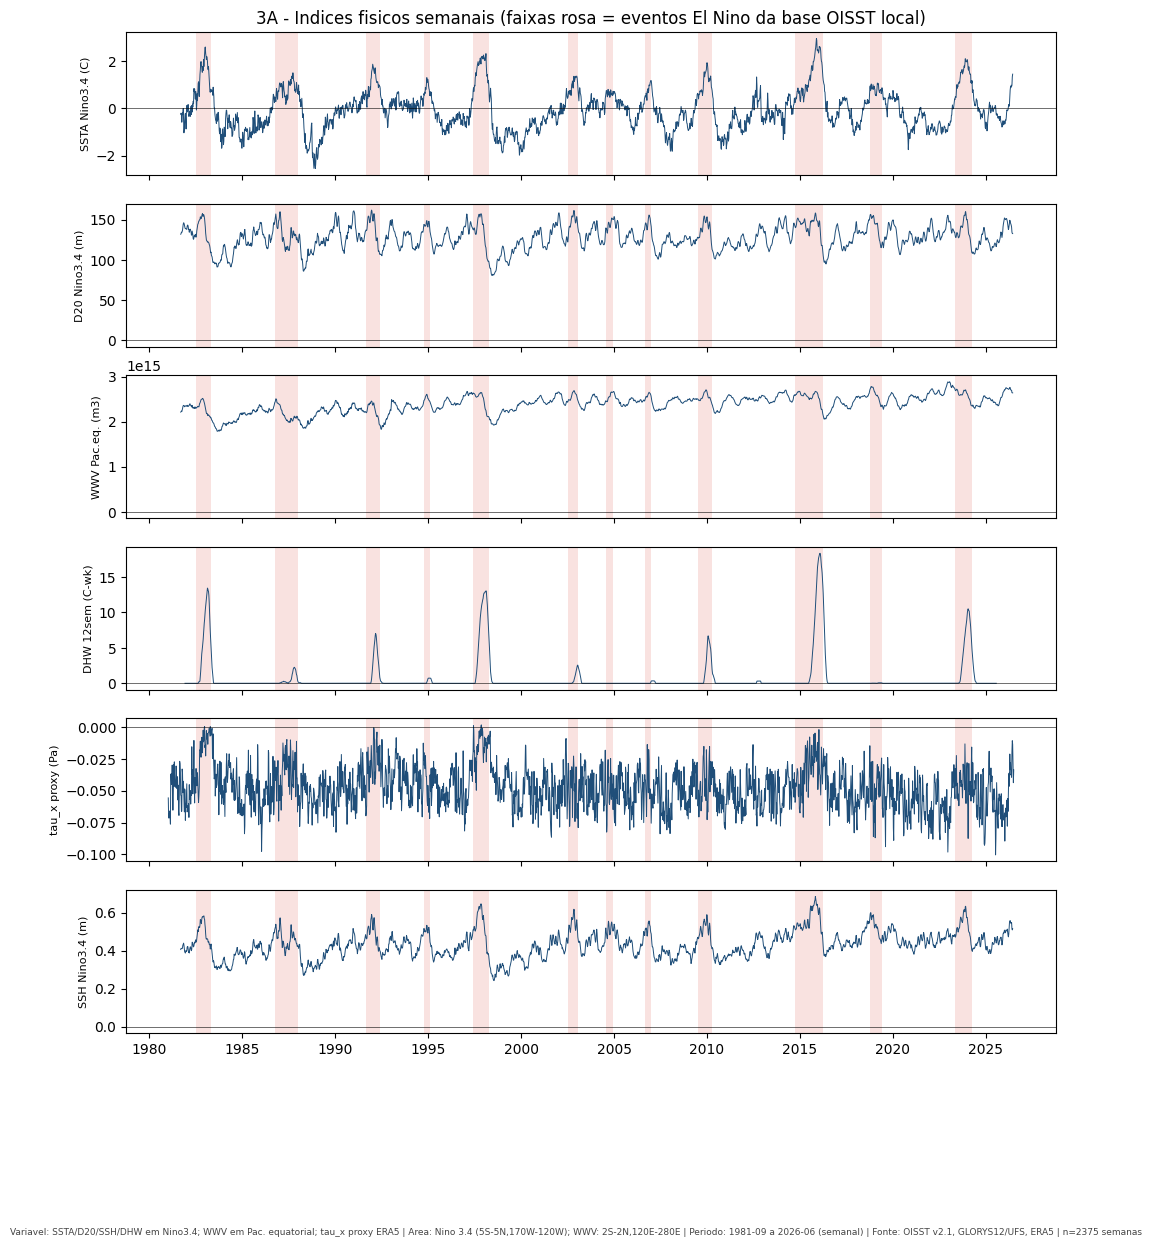

In [3]:
ev=u.load_events()
paineis=[('nino34_ssta','SSTA Nino3.4 (C)'),('d20_m','D20 Nino3.4 (m)'),('wwv','WWV Pac.eq. (m3)'),
 ('dhw_12w','DHW 12sem (C-wk)'),('tau_x_proxy_nino34_pa','tau_x proxy (Pa)'),('ssh_m','SSH Nino3.4 (m)')]
fig,axes=plt.subplots(len(paineis),1,figsize=(12,13),sharex=True)
for ax,(c,lab) in zip(axes,paineis):
    ax.plot(weekly.index,weekly[c],lw=.7,color='#1f4e79'); u.add_event_shading(ax,ev); ax.set_ylabel(lab,fontsize=8); ax.axhline(0,color='k',lw=.4)
axes[0].set_title('3A - Indices fisicos semanais (faixas rosa = eventos El Nino da base OISST local)')
u.stamp_caption(fig,variavel='SSTA/D20/SSH/DHW em Nino3.4; WWV em Pac. equatorial; tau_x proxy ERA5',
 area='Nino 3.4 (5S-5N,170W-120W); WWV: 2S-2N,120E-280E',periodo='1981-09 a 2026-06 (semanal)',
 fonte='OISST v2.1, GLORYS12/UFS, ERA5',n=f'{len(weekly)} semanas')
u.save_fig(fig,'phase3A_series_semanais.png'); plt.show()

[figura] data/processed/figures/fase3/phase3A_hovmoller_panorama.png


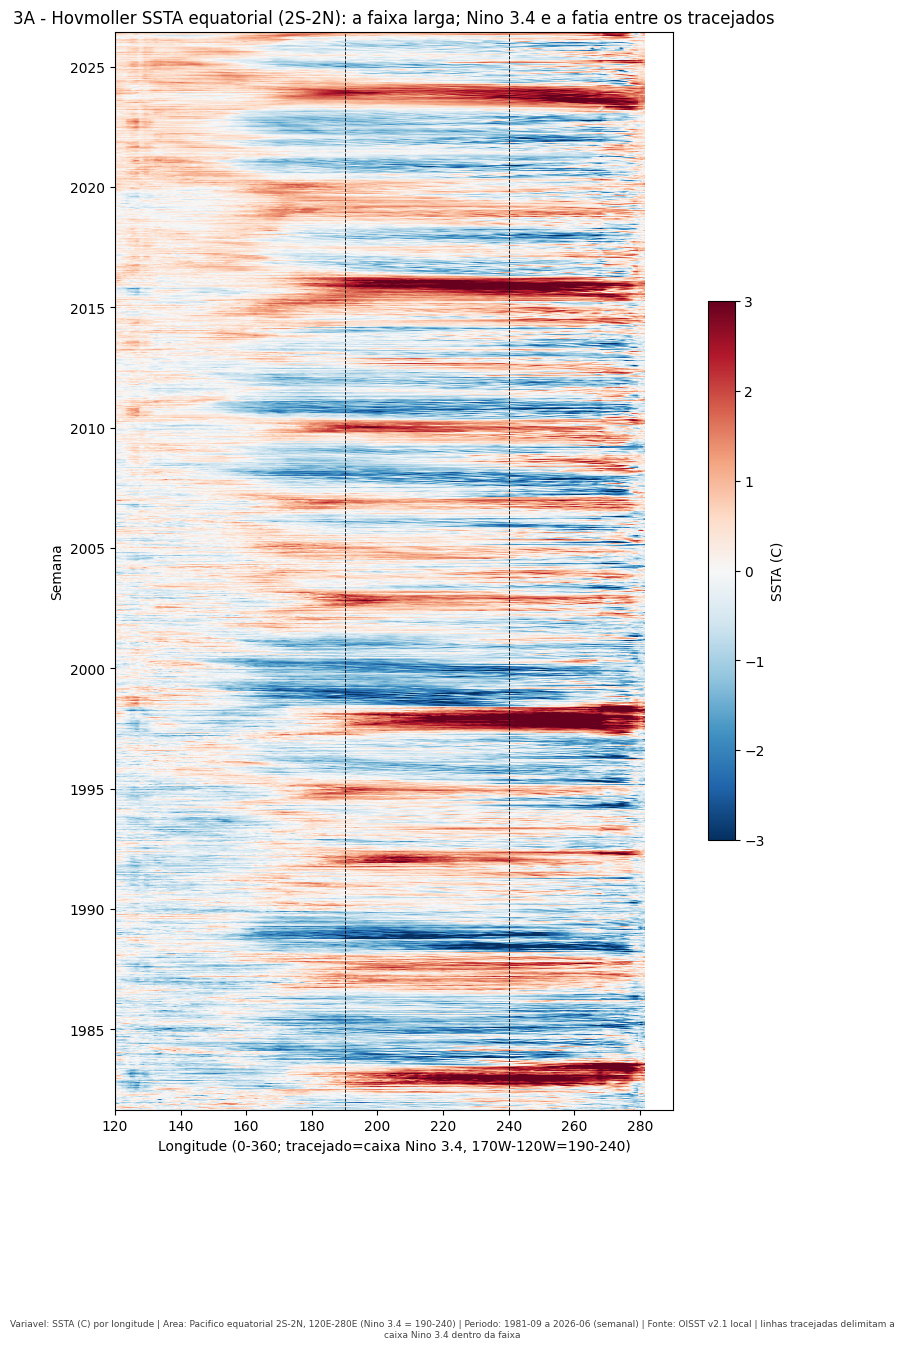

In [4]:
eq=u.load_eqband_weekly()
fig,ax=plt.subplots(figsize=(9,14)); lon=eq.columns.values
pc=ax.pcolormesh(lon,eq.index,eq.values,cmap='RdBu_r',vmin=-3,vmax=3,shading='auto')
ax.axvline(190,color='k',ls='--',lw=.6); ax.axvline(240,color='k',ls='--',lw=.6)
ax.set_xlabel('Longitude (0-360; tracejado=caixa Nino 3.4, 170W-120W=190-240)'); ax.set_ylabel('Semana')
ax.set_title('3A - Hovmoller SSTA equatorial (2S-2N): a faixa larga; Nino 3.4 e a fatia entre os tracejados')
fig.colorbar(pc,ax=ax,label='SSTA (C)',shrink=.5)
u.stamp_caption(fig,variavel='SSTA (C) por longitude',area='Pacifico equatorial 2S-2N, 120E-280E (Nino 3.4 = 190-240)',
 periodo='1981-09 a 2026-06 (semanal)',fonte='OISST v2.1 local',extra='linhas tracejadas delimitam a caixa Nino 3.4 dentro da faixa')
u.save_fig(fig,'phase3A_hovmoller_panorama.png'); plt.show()

**Leitura do 3A.** A matriz cobre 1981-2026 na superficie e subsuperficie (esta com ressalva de emenda UFS 1981-92 -> GLORYS12 1993+). **O Hovmoller torna explicita a diferenca geografica:** o eixo horizontal inteiro (120E-280E) e o *Pacifico equatorial*; a fatia entre os tracejados (170W-120W) e o *Nino 3.4*. As faixas quentes de 1982/97/2015/2023 nascem a oeste e migram para dentro da caixa Nino 3.4 - o que motiva o estudo de precursores por longitude no 3C.